In [ ]:
# ================================================================
# CELL 1: Mount Google Drive
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ================================================================
# CELL 2: Install Libraries
# ================================================================

!pip install rasterio opencv-python

In [ ]:
# ================================================================
# CELL 3: Imports and Setup
# ================================================================

import os
import gc
import json
import numpy as np
import rasterio
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

tf.get_logger().setLevel('ERROR')

# Where to save all results
RESULTS_DIR = "/content/drive/MyDrive/Research/all_experiment_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

RESULTS_FILE = os.path.join(RESULTS_DIR, "master_results.json")

print("Setup complete!")
print(f"Results will be saved to: {RESULTS_DIR}")

Setup complete!
Results will be saved to: /content/drive/MyDrive/Research/all_experiment_results


In [ ]:
# ================================================================
# CELL 4: Image Loading Functions
# ================================================================

IMG_SIZE = 64
NORMALIZE_DIV = 10000.0

def load_rgb_image(tif_path):
    with rasterio.open(tif_path) as src:
        img = src.read([4, 3, 2]).astype(np.float32)
    img = np.transpose(img, (1, 2, 0))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    img = img / NORMALIZE_DIV
    return img

def load_13band_image(tif_path):
    with rasterio.open(tif_path) as src:
        if src.count < 13:
            raise ValueError(f"{tif_path} has {src.count} bands, expected 13.")
        img = src.read(list(range(1, 14))).astype(np.float32)
    img = np.transpose(img, (1, 2, 0))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    img = img / NORMALIZE_DIV
    return img

print("Image loading functions ready!")

Image loading functions ready!


In [ ]:
# ================================================================
# CELL 5: Dataset Loading Function
# ================================================================

def load_dataset(dataset_path, num_bands=3):
    X = []
    y = []

    class_names = sorted(os.listdir(dataset_path))
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    load_fn = load_rgb_image if num_bands == 3 else load_13band_image

    for class_name in class_names:
        class_folder = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_folder):
            continue
        label = class_to_idx[class_name]

        for file in os.listdir(class_folder):
            if file.endswith(".tif"):
                img_path = os.path.join(class_folder, file)
                img = load_fn(img_path)
                X.append(img)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    return X, y, class_names


def split_dataset(X, y):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

print("Dataset functions ready!")

Dataset functions ready!


In [ ]:
# ================================================================
# CELL 6: Baseline CNN Model
#
# CORRECT BASELINE ARCHITECTURE:
#   3 conv layers, filters [32, 64, 128], kernel 3x3,
#   ReLU activation, dropout 0.5
# ================================================================

def build_baseline_cnn(input_shape, num_classes=10):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    # Conv block 1
    model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Conv block 2
    model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Conv block 3
    model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Classification head
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Verify architecture
print("Baseline CNN Architecture:")
print("  Conv layers: 3")
print("  Filters: [32, 64, 128]")
print("  Kernel: 3x3")
print("  Activation: relu")
print("  Dropout: 0.5")
print("  Dense: 128 → 10 (softmax)")

Baseline CNN Architecture:
  Conv layers: 3
  Filters: [32, 64, 128]
  Kernel: 3x3
  Activation: relu
  Dropout: 0.5
  Dense: 128 → 10 (softmax)


In [ ]:
# ================================================================
# CELL 7: Run Single Experiment Function
# ================================================================

def run_baseline_experiment(dataset_path, num_bands, num_images_label):
    experiment_name = f"baseline_{num_bands}band_{num_images_label}img"
    print(f"\n{'='*60}")
    print(f"  RUNNING: {experiment_name}")
    print(f"  Bands: {num_bands}, Images: {num_images_label}")
    print(f"{'='*60}")

    tf.keras.backend.clear_session()
    gc.collect()

    # Load data
    print("Loading dataset...")
    X, y, class_names = load_dataset(dataset_path, num_bands=num_bands)
    print(f"  Loaded: X={X.shape}, y={y.shape}")

    # Split
    X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)
    print(f"  Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    del X, y
    gc.collect()

    # Build model
    input_shape = (IMG_SIZE, IMG_SIZE, num_bands)
    model = build_baseline_cnn(input_shape)
    model.summary()

    # Training callbacks
    my_callbacks = [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

    # Train
    print("Training...")
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=my_callbacks,
        verbose=1
    )

    # Evaluate
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"\n📊 Validation Accuracy: {val_acc:.4f}")
    print(f"📊 Test Accuracy:       {test_acc:.4f}")

    # Predictions and metrics
    y_pred = np.argmax(model.predict(X_test), axis=1)

    report = classification_report(
        y_test, y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True
    )

    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    history_dict = {
        'accuracy': [float(x) for x in history.history['accuracy']],
        'val_accuracy': [float(x) for x in history.history['val_accuracy']],
        'loss': [float(x) for x in history.history['loss']],
        'val_loss': [float(x) for x in history.history['val_loss']],
    }

    result = {
        'experiment_name': experiment_name,
        'num_bands': num_bands,
        'num_images': num_images_label,
        'model_type': 'baseline',
        'architecture': {
            'num_conv_layers': 3,
            'filters_list': [32, 64, 128],
            'kernel_size': 3,
            'activation': 'relu',
            'dropout_rate': 0.5
        },
        'train_size': int(X_train.shape[0]),
        'val_size': int(X_val.shape[0]),
        'test_size': int(X_test.shape[0]),
        'val_accuracy': float(val_acc),
        'test_accuracy': float(test_acc),
        'val_loss': float(val_loss),
        'test_loss': float(test_loss),
        'epochs_trained': len(history.history['accuracy']),
        'macro_precision': float(report['macro avg']['precision']),
        'macro_recall': float(report['macro avg']['recall']),
        'macro_f1': float(report['macro avg']['f1-score']),
        'per_class_f1': {cls: float(report[cls]['f1-score']) for cls in class_names},
        'confusion_matrix': cm.tolist(),
        'history': history_dict
    }

    # Save model
    model_save_path = os.path.join(RESULTS_DIR, f'{experiment_name}_model.h5')
    model.save(model_save_path)
    print(f"💾 Model saved to {model_save_path}")

    del model, X_train, X_val, X_test, y_train, y_val, y_test
    gc.collect()

    print(f"✅ {experiment_name} complete!")
    return result

In [ ]:
# ================================================================
# CELL 8: Extract Datasets
# ================================================================

import zipfile

DATASET_100 = "/content/drive/MyDrive/Research/dataset/dataset_100/dataset.zip"
DATASET_500 = "/content/drive/MyDrive/Research/dataset/dataset_500/dataset.zip"

EXTRACT_100 = "/content/data/dataset_100"
EXTRACT_500 = "/content/data/dataset_500"

print("Extracting datasets...")

for zip_path, extract_path in [(DATASET_100, EXTRACT_100), (DATASET_500, EXTRACT_500)]:
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print(f"  ✅ Extracted: {zip_path}")
    else:
        print(f"  ❌ Not found: {zip_path}")

def find_dataset_folder(extract_path):
    for root, dirs, files in os.walk(extract_path):
        has_tif = False
        for d in dirs:
            subfolder = os.path.join(root, d)
            if any(f.endswith('.tif') for f in os.listdir(subfolder)):
                has_tif = True
                break
        if has_tif:
            return root
    return extract_path

DATASET_PATH_1000 = find_dataset_folder(EXTRACT_100)
DATASET_PATH_5000 = find_dataset_folder(EXTRACT_500)

print(f"\n1000-image dataset path: {DATASET_PATH_1000}")
print(f"5000-image dataset path: {DATASET_PATH_5000}")

Extracting datasets...
  ✅ Extracted: /content/drive/MyDrive/Research/dataset/dataset_100/dataset.zip
  ✅ Extracted: /content/drive/MyDrive/Research/dataset/dataset_500/dataset.zip

1000-image dataset path: /content/data/dataset_100
5000-image dataset path: /content/data/dataset_500


In [ ]:
# ================================================================
# CELL 9: Run All 4 Baseline Experiments
# ================================================================

experiments = [
    {"dataset_path": DATASET_PATH_1000, "num_bands": 3,  "num_images": "1000"},
    {"dataset_path": DATASET_PATH_1000, "num_bands": 13, "num_images": "1000"},
    {"dataset_path": DATASET_PATH_5000, "num_bands": 3,  "num_images": "5000"},
    {"dataset_path": DATASET_PATH_5000, "num_bands": 13, "num_images": "5000"},
]

all_results = []

for i, exp in enumerate(experiments):
    print(f"\n{'#'*60}")
    print(f"  EXPERIMENT {i+1} of {len(experiments)}")
    print(f"{'#'*60}")

    result = run_baseline_experiment(
        dataset_path=exp["dataset_path"],
        num_bands=exp["num_bands"],
        num_images_label=exp["num_images"]
    )
    all_results.append(result)

    # Save after each experiment
    save_data = {
        'baseline_architecture': {
            'num_conv_layers': 3,
            'filters_list': [32, 64, 128],
            'kernel_size': 3,
            'activation': 'relu',
            'dropout_rate': 0.5
        },
        'experiments': all_results,
        'cmaes_experiments': {}
    }
    with open(RESULTS_FILE, 'w') as f:
        json.dump(save_data, f, indent=2)
    print(f"💾 Progress saved ({i+1}/{len(experiments)} done)")

print(f"\n{'='*60}")
print(f"  ALL {len(experiments)} BASELINE EXPERIMENTS COMPLETE!")
print(f"{'='*60}")


############################################################
  EXPERIMENT 1 of 4
############################################################

  RUNNING: baseline_3band_1000img
  Bands: 3, Images: 1000
Loading dataset...
  Loaded: X=(1000, 64, 64, 3), y=(1000,)
  Train: (700, 64, 64, 3), Val: (150, 64, 64, 3), Test: (150, 64, 64, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,242 (4.36 MB)

 Trainable params: 1,143,242 (4.36 MB)

...

 Total params: 1,146,122 (4.37 MB)

 Trainable params: 1,146,122 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

Training...
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.3789 - loss: 1.6907 - val_accuracy: 0.5213 - val_loss: 1.2253 - learning_rate: 0.0010
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5474 - loss: 1.2489 - val_accuracy: 0.6693 - val_loss: 0.9128 - learning_rate: 0.0010
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6271 - loss: 1.0554 - val_accuracy: 0.6880 - val_loss: 0.9001 - learning_rate: 0.0010
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6783 - loss: 0.8910 - val_accuracy: 0.7147 - val_loss: 0.8802 - learning_rate: 0.0010
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7217 - loss: 0.7869 - val_accuracy: 0.7507 - val_loss: 0.7721 - learning_rate: 0.0010
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7543 - loss: 0.6968 - val_accuracy: 0.7573 - val_loss: 0.7366 - learning_rate: 0.0010
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy


Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop     0.8052    0.8267    0.8158        75
              Forest     0.9863    0.9600    0.9730        75
HerbaceousVegetation     0.9000    0.8400    0.8690        75
             Highway     0.8676    0.7867    0.8252        75
          Industrial     0.8780    0.9600    0.9172        75
             Pasture     0.8554    0.9467    0.8987        75
       PermanentCrop     0.8219    0.8000    0.8108        75
         Residential     0.8701    0.8933    0.8816        75
               River     0.9861    0.9467    0.9660        75
             SeaLake     1.0000    1.0000    1.0000        75

            accuracy                         0.8960       750
           macro avg     0.8971    0.8960    0.8957       750
        weighted avg     0.8971    0.8960    0.8957       750

💾 Model saved to /content/drive/MyDrive/Research/all_experiment_results/baseline_13band_5000img_model.h5


In [ ]:
# ================================================================
# CELL 10: Master Results Table
# ================================================================

with open(RESULTS_FILE, 'r') as f:
    saved_data = json.load(f)

baseline_results = saved_data['experiments']

print("=" * 100)
print("  MASTER RESULTS TABLE — BASELINE CNN")
print("  Architecture: 3 conv layers, [32, 64, 128] filters, 3x3 kernel, ReLU, dropout=0.5")
print("=" * 100)
print(f"{'Experiment':<30} {'Bands':>6} {'Images':>7} {'Train':>6} {'Val':>5} {'Test':>5} {'Val Acc':>9} {'Test Acc':>9} {'F1':>7} {'Epochs':>7}")
print("-" * 100)

for r in baseline_results:
    label = f"Baseline {r['num_bands']}-band {r['num_images']}img"
    print(f"{label:<30} "
          f"{r['num_bands']:>6} "
          f"{r['num_images']:>7} "
          f"{r['train_size']:>6} "
          f"{r['val_size']:>5} "
          f"{r['test_size']:>5} "
          f"{r['val_accuracy']:>9.4f} "
          f"{r['test_accuracy']:>9.4f} "
          f"{r['macro_f1']:>7.4f} "
          f"{r['epochs_trained']:>7}")

print("-" * 100)

# Effect of bands
print(f"\n{'='*55}")
print("  EFFECT OF SPECTRAL BANDS (3-band vs 13-band)")
print(f"{'='*55}")
print(f"{'Dataset Size':<15} {'3-band Test':>12} {'13-band Test':>13} {'Improvement':>12}")
print("-" * 52)

for size in ["1000", "5000"]:
    r3 = next((r for r in baseline_results if r['num_bands'] == 3 and r['num_images'] == size), None)
    r13 = next((r for r in baseline_results if r['num_bands'] == 13 and r['num_images'] == size), None)
    if r3 and r13:
        diff = r13['test_accuracy'] - r3['test_accuracy']
        print(f"{size + ' images':<15} {r3['test_accuracy']:>12.4f} {r13['test_accuracy']:>13.4f} {diff:>+12.4f}")

# Effect of dataset size
print(f"\n{'='*50}")
print("  EFFECT OF DATASET SIZE (1000 vs 5000 images)")
print(f"{'='*50}")
print(f"{'Band Config':<15} {'1000 Test':>10} {'5000 Test':>10} {'Improvement':>12}")
print("-" * 47)

for bands in [3, 13]:
    r1k = next((r for r in baseline_results if r['num_bands'] == bands and r['num_images'] == "1000"), None)
    r5k = next((r for r in baseline_results if r['num_bands'] == bands and r['num_images'] == "5000"), None)
    if r1k and r5k:
        diff = r5k['test_accuracy'] - r1k['test_accuracy']
        print(f"{str(bands) + '-band':<15} {r1k['test_accuracy']:>10.4f} {r5k['test_accuracy']:>10.4f} {diff:>+12.4f}")

# Placeholder table for CMA-ES
print(f"\n{'='*95}")
print("  FULL COMPARISON TABLE (Baseline vs CMA-ES)")
print("  ⚠️  CMA-ES columns: fill after running CMA-ES experiments (use Cell 12)")
print(f"{'='*95}")
print(f"{'Configuration':<25} {'Baseline Val':>12} {'Baseline Test':>13} {'CMA-ES Val':>11} {'CMA-ES Test':>12} {'Improvement':>12}")
print("-" * 95)

for r in baseline_results:
    label = f"{r['num_bands']}-band, {r['num_images']} imgs"
    print(f"{label:<25} {r['val_accuracy']:>12.4f} {r['test_accuracy']:>13.4f} {'---':>11} {'---':>12} {'---':>12}")

print("-" * 95)

  MASTER RESULTS TABLE — BASELINE CNN
  Architecture: 3 conv layers, [32, 64, 128] filters, 3x3 kernel, ReLU, dropout=0.5
Experiment                      Bands  Images  Train   Val  Test   Val Acc  Test Acc      F1  Epochs
----------------------------------------------------------------------------------------------------
Baseline 3-band 1000img             3    1000    700   150   150    0.6800    0.6800  0.6759      33
Baseline 13-band 1000img           13    1000    700   150   150    0.8000    0.8267  0.8246      42
Baseline 3-band 5000img             3    5000   3500   750   750    0.8147    0.8067  0.8029      32
Baseline 13-band 5000img           13    5000   3500   750   750    0.8693    0.8960  0.8957      25
----------------------------------------------------------------------------------------------------

  EFFECT OF SPECTRAL BANDS (3-band vs 13-band)
Dataset Size     3-band Test  13-band Test  Improvement
----------------------------------------------------
1000 images   

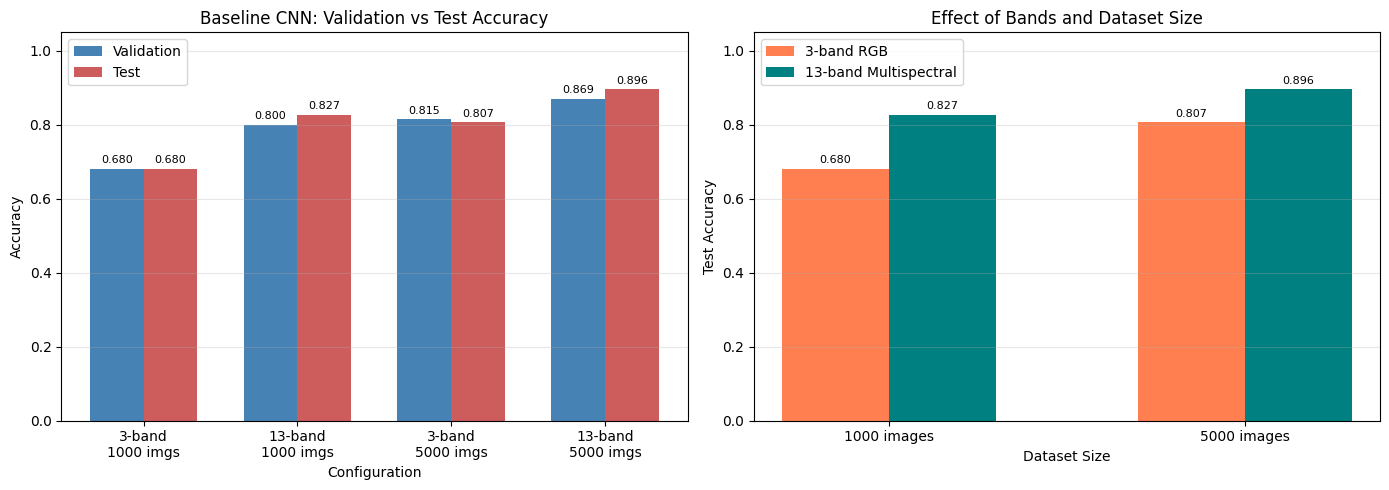

💾 Comparison charts saved!


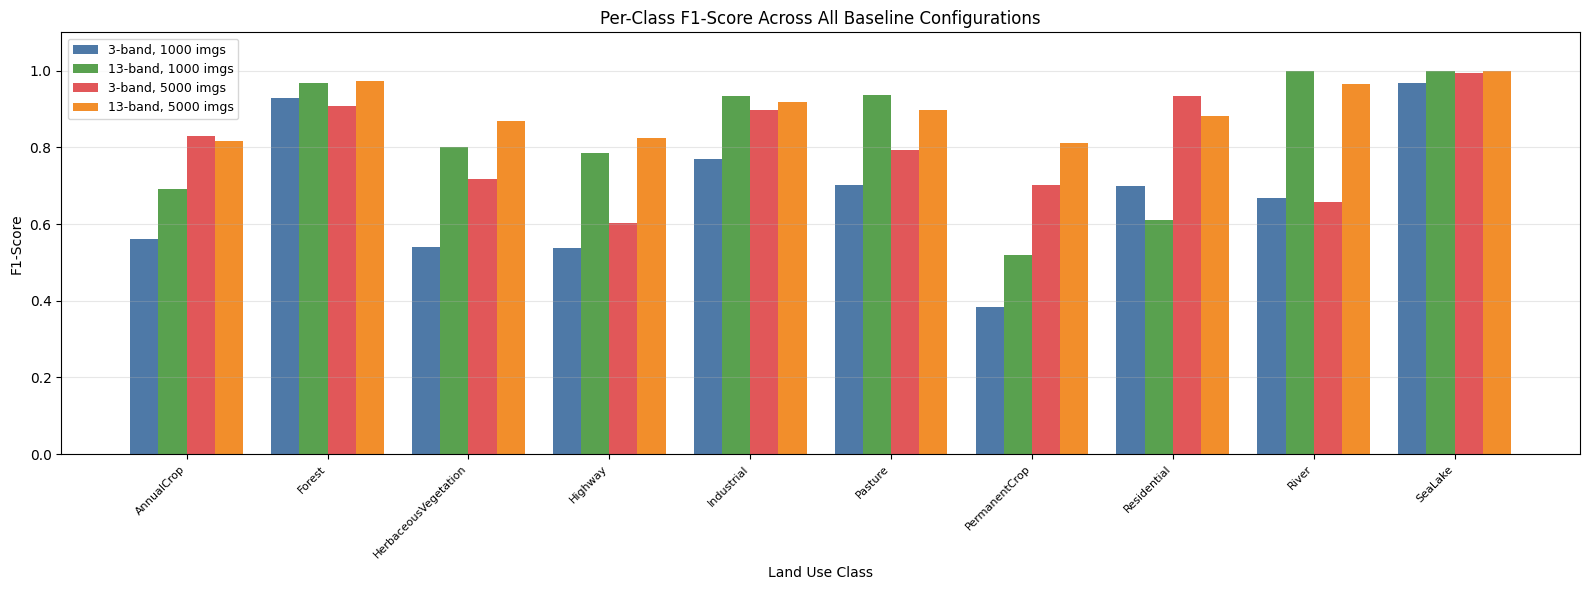

💾 Per-class F1 chart saved!


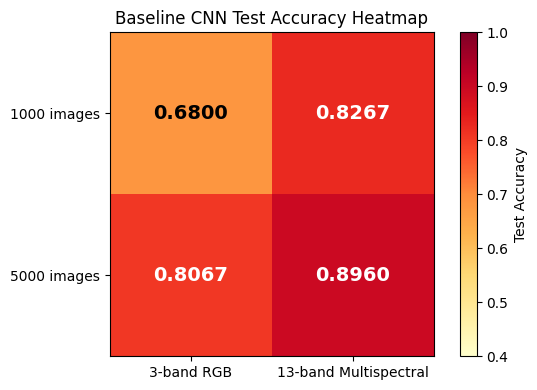

💾 Heatmap saved!


In [ ]:
# ================================================================
# CELL 11: Generate Charts
# ================================================================

# ---- Chart 1: Accuracy bar chart ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [f"{r['num_bands']}-band\n{r['num_images']} imgs" for r in baseline_results]
val_accs = [r['val_accuracy'] for r in baseline_results]
test_accs = [r['test_accuracy'] for r in baseline_results]

x = np.arange(len(labels))
width = 0.35

axes[0].bar(x - width/2, val_accs, width, label='Validation', color='steelblue')
axes[0].bar(x + width/2, test_accs, width, label='Test', color='indianred')
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Baseline CNN: Validation vs Test Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, axis='y', alpha=0.3)

for i, (v, t) in enumerate(zip(val_accs, test_accs)):
    axes[0].text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    axes[0].text(i + width/2, t + 0.01, f'{t:.3f}', ha='center', va='bottom', fontsize=8)

# ---- Chart 2: Bands vs size grouped ----
configs = {
    '3-band': {'1000': None, '5000': None},
    '13-band': {'1000': None, '5000': None}
}
for r in baseline_results:
    key = f"{r['num_bands']}-band"
    configs[key][r['num_images']] = r['test_accuracy']

x = np.arange(2)
width = 0.3

axes[1].bar(x - width/2, [configs['3-band']['1000'] or 0, configs['3-band']['5000'] or 0],
            width, label='3-band RGB', color='coral')
axes[1].bar(x + width/2, [configs['13-band']['1000'] or 0, configs['13-band']['5000'] or 0],
            width, label='13-band Multispectral', color='teal')
axes[1].set_xlabel('Dataset Size')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Effect of Bands and Dataset Size')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['1000 images', '5000 images'])
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, axis='y', alpha=0.3)

for i in range(2):
    sizes = ['1000', '5000']
    v3 = configs['3-band'][sizes[i]] or 0
    v13 = configs['13-band'][sizes[i]] or 0
    axes[1].text(i - width/2, v3 + 0.01, f'{v3:.3f}', ha='center', va='bottom', fontsize=8)
    axes[1].text(i + width/2, v13 + 0.01, f'{v13:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'baseline_comparison_charts.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f"💾 Comparison charts saved!")


# ---- Chart 3: Per-class F1 across all 4 configs ----
fig, ax = plt.subplots(figsize=(16, 6))

class_names_short = list(baseline_results[0]['per_class_f1'].keys())
x = np.arange(len(class_names_short))
width = 0.2
colors = ['#4e79a7', '#59a14f', '#e15759', '#f28e2b']

for i, r in enumerate(baseline_results):
    f1_values = [r['per_class_f1'][cls] for cls in class_names_short]
    label = f"{r['num_bands']}-band, {r['num_images']} imgs"
    ax.bar(x + (i - 1.5) * width, f1_values, width, label=label, color=colors[i])

ax.set_xlabel('Land Use Class')
ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1-Score Across All Baseline Configurations')
ax.set_xticks(x)
ax.set_xticklabels(class_names_short, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.1)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'baseline_per_class_f1_all.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f"💾 Per-class F1 chart saved!")


# ---- Chart 4: Accuracy heatmap ----
fig, ax = plt.subplots(figsize=(6, 4))

heatmap_data = np.zeros((2, 2))
for r in baseline_results:
    row = 0 if r['num_images'] == '1000' else 1
    col = 0 if r['num_bands'] == 3 else 1
    heatmap_data[row, col] = r['test_accuracy']

im = ax.imshow(heatmap_data, cmap='YlOrRd', vmin=0.4, vmax=1.0)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['3-band RGB', '13-band Multispectral'])
ax.set_yticklabels(['1000 images', '5000 images'])
ax.set_title('Baseline CNN Test Accuracy Heatmap')
plt.colorbar(im, ax=ax, label='Test Accuracy')

for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{heatmap_data[i, j]:.4f}',
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if heatmap_data[i, j] > 0.7 else 'black')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'baseline_accuracy_heatmap.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f"💾 Heatmap saved!")

In [ ]:
# # ================================================================
# # CELL 12: Add CMA-ES Results Later
# #
# # ⚠️ RUN THIS CELL ONLY AFTER YOU COMPLETE CMA-ES EXPERIMENTS
# # Update the values below with your CMA-ES results, then run.
# # ================================================================

# cmaes_results = {
#     "3-band_1000": {
#         "val_accuracy": None,
#         "test_accuracy": None,
#         "architecture": None
#     },
#     "13-band_1000": {
#         "val_accuracy": None,
#         "test_accuracy": None,
#         "architecture": None
#     },
#     "3-band_5000": {
#         "val_accuracy": None,
#         "test_accuracy": None,
#         "architecture": None
#     },
#     "13-band_5000": {
#         "val_accuracy": None,
#         "test_accuracy": None,
#         "architecture": None
#     }
# }

# with open(RESULTS_FILE, 'r') as f:
#     saved_data = json.load(f)

# baseline_results = saved_data['experiments']
# saved_data['cmaes_experiments'] = cmaes_results

# with open(RESULTS_FILE, 'w') as f:
#     json.dump(saved_data, f, indent=2)

# print("=" * 95)
# print("  COMPLETE COMPARISON: BASELINE vs CMA-ES")
# print("  Baseline: 3 conv layers, [32,64,128], kernel 3, relu, dropout 0.5")
# print("=" * 95)
# print(f"{'Configuration':<25} {'Baseline Val':>12} {'Baseline Test':>13} {'CMA-ES Val':>11} {'CMA-ES Test':>12} {'Improvement':>12}")
# print("-" * 95)

# for r in baseline_results:
#     key = f"{r['num_bands']}-band_{r['num_images']}"
#     label = f"{r['num_bands']}-band, {r['num_images']} imgs"

#     cmaes = cmaes_results.get(key, {})
#     c_val = cmaes.get('val_accuracy')
#     c_test = cmaes.get('test_accuracy')

#     c_val_str = f"{c_val:.4f}" if c_val else "---"
#     c_test_str = f"{c_test:.4f}" if c_test else "---"
#     diff_str = f"{c_test - r['test_accuracy']:+.4f}" if c_test else "---"

#     print(f"{label:<25} {r['val_accuracy']:>12.4f} {r['test_accuracy']:>13.4f} {c_val_str:>11} {c_test_str:>12} {diff_str:>12}")

# print("-" * 95)

# has_cmaes = any(v['test_accuracy'] is not None for v in cmaes_results.values())

# if has_cmaes:
#     fig, ax = plt.subplots(figsize=(12, 5))

#     labels_list = []
#     baseline_test_list = []
#     cmaes_test_list = []

#     for r in baseline_results:
#         key = f"{r['num_bands']}-band_{r['num_images']}"
#         cmaes = cmaes_results.get(key, {})
#         c_test = cmaes.get('test_accuracy')

#         if c_test is not None:
#             labels_list.append(f"{r['num_bands']}-band\n{r['num_images']} imgs")
#             baseline_test_list.append(r['test_accuracy'])
#             cmaes_test_list.append(c_test)

#     if labels_list:
#         x = np.arange(len(labels_list))
#         width = 0.3

#         bars1 = ax.bar(x - width/2, baseline_test_list, width, label='Baseline CNN', color='steelblue')
#         bars2 = ax.bar(x + width/2, cmaes_test_list, width, label='CMA-ES CNN', color='indianred')

#         ax.set_xlabel('Configuration')
#         ax.set_ylabel('Test Accuracy')
#         ax.set_title('Baseline vs CMA-ES: Test Accuracy Comparison')
#         ax.set_xticks(x)
#         ax.set_xticklabels(labels_list)
#         ax.legend(fontsize=11)
#         ax.set_ylim(0, 1.05)
#         ax.grid(True, axis='y', alpha=0.3)

#         for bar in bars1:
#             h = bar.get_height()
#             ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.3f}', ha='center', fontsize=9)
#         for bar in bars2:
#             h = bar.get_height()
#             ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.3f}', ha='center', fontsize=9)

#         plt.tight_layout()
#         plt.savefig(os.path.join(RESULTS_DIR, 'baseline_vs_cmaes_comparison.png'), dpi=200, bbox_inches='tight')
#         plt.show()
#         print(f"💾 Comparison chart saved!")
# else:
#     print("\n⚠️  No CMA-ES results yet. Fill in the values above and re-run this cell.")

# print(f"\n💾 All results saved to: {RESULTS_FILE}")